# Table of Contents
1. [Introduction](#Introduction)
2. [Data Loading](#Data-Loading)
3. [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
4. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
5. [Feature Engineering](#Feature-Engineering)
6. [Model Building and Evaluation](#Model-Building-and-Evaluation)
7. [Discussion and Conclusion](#Discussion-and-Conclusion)

# Data Loading
Let's begin by loading the datasets and taking a preliminary look at the data.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Load the datasets
loan_data_dict = pd.read_csv('/input/loan-application-risk-prediction-data/loan_data_dictionary.csv')
loan_applications = pd.read_csv('/input/loan-application-risk-prediction-data/loan_applications.csv')
credit_features = pd.read_csv('/input/loan-application-risk-prediction-data/credit_features_subset.csv')

# Display the first few rows of each dataset
loan_data_dict.head(), loan_applications.head(), credit_features.head()

(               Name                              Description
 0               UID                        unique identifier
 1  Application Date                 Date of loan application
 2            Amount            Amount requested by applicant
 3              Term  Repayment period requested by applicant
 4   Employment Type                        Stated employment,
        UID ApplicationDate  Amount  Term        EmploymentType  \
 0  4921736      03/07/2020    2000    60  Employed - full time   
 1  1241981      04/02/2020    3000    60  Employed - full time   
 2  5751748      02/08/2020   20000    60  Employed - full time   
 3  7163425      23/09/2020   20000    60         Self employed   
 4   227377      01/01/2020    5000    36  Employed - full time   
 
               LoanPurpose  Success  
 0        Unexpected bills        0  
 1  Starting new bussniess        0  
 2        Business capital        0  
 3    New business venture        0  
 4                     car       

# Data Cleaning and Preprocessing
Before diving into analysis, it's essential to clean and preprocess the data. This includes handling missing values, converting data types, and merging datasets where necessary.

In [2]:
# Convert ApplicationDate to datetime
# The date format seems to be day first, so we will specify dayfirst=True
loan_applications['ApplicationDate'] = pd.to_datetime(loan_applications['ApplicationDate'], dayfirst=True)

# Merge loan applications with credit features on UID
merged_data = pd.merge(loan_applications, credit_features, on='UID')

# Check for missing values
merged_data.isnull().sum()

UID                                     0
ApplicationDate                         0
Amount                                  0
Term                                    0
EmploymentType                          0
LoanPurpose                             0
Success                                 0
ALL_AgeOfOldestAccount                  0
ALL_AgeOfYoungestAccount                0
ALL_Count                               0
ALL_CountActive                         0
ALL_CountClosedLast12Months             0
ALL_CountDefaultAccounts                0
ALL_CountOpenedLast12Months             0
ALL_CountSettled                        0
ALL_MeanAccountAge                      0
ALL_SumCurrentOutstandingBal            0
ALL_SumCurrentOutstandingBalExcMtg      0
ALL_TimeSinceMostRecentDefault          0
ALL_WorstPaymentStatusActiveAccounts    0
dtype: int64

# Exploratory Data Analysis
With the data cleaned, let's explore it to uncover patterns and insights.

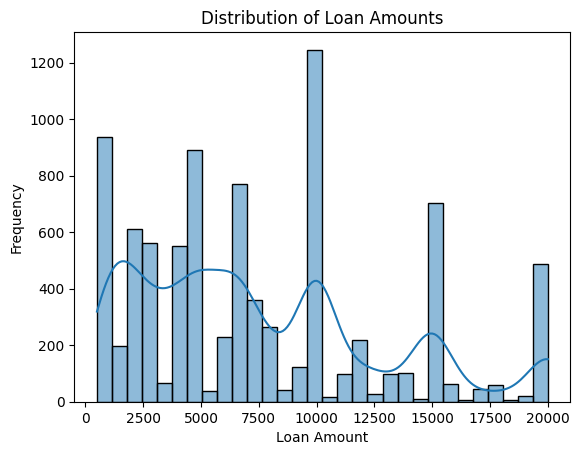

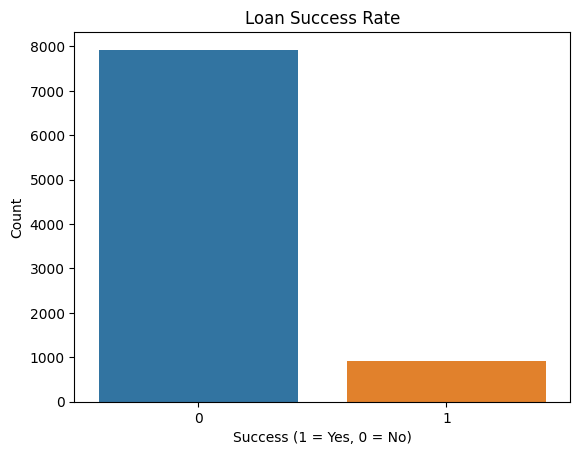

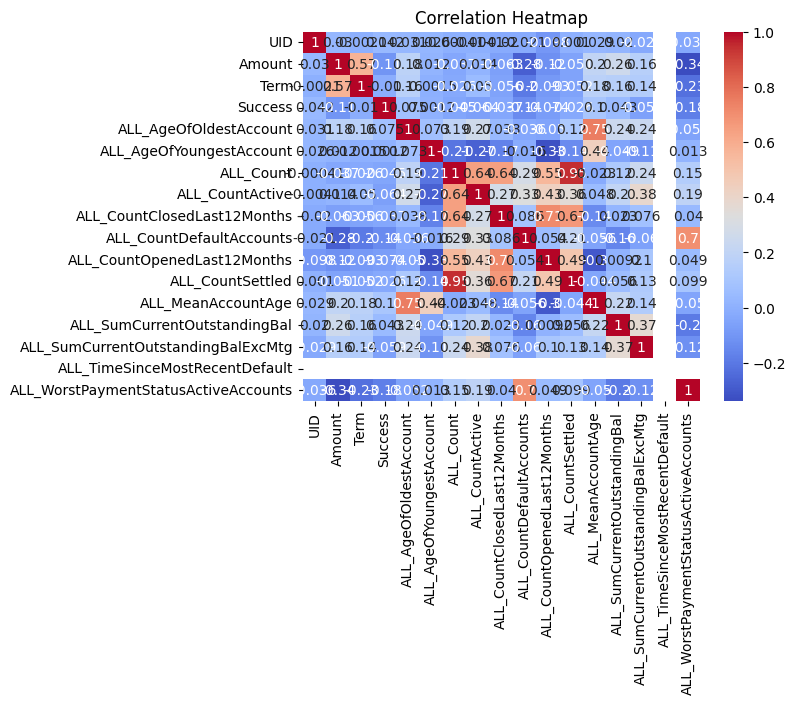

In [3]:
# Visualize the distribution of loan amounts
sns.histplot(merged_data['Amount'], bins=30, kde=True)
plt.title('Distribution of Loan Amounts')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

# Visualize the success rate of loans
sns.countplot(x='Success', data=merged_data)
plt.title('Loan Success Rate')
plt.xlabel('Success (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

# Correlation heatmap of numeric features
numeric_df = merged_data.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Feature Engineering
Feature engineering can enhance the predictive power of our model. Let's create some new features based on the existing data.

In [4]:
# Create a feature for the ratio of active accounts to total accounts
merged_data['ActiveAccountRatio'] = merged_data['ALL_CountActive'] / merged_data['ALL_Count']

# Create a feature for the ratio of closed accounts in the last 12 months to total accounts
merged_data['ClosedLast12MonthsRatio'] = merged_data['ALL_CountClosedLast12Months'] / merged_data['ALL_Count']

# Check the new features
merged_data[['ActiveAccountRatio', 'ClosedLast12MonthsRatio']].head()

,ActiveAccountRatio,ClosedLast12MonthsRatio
0,0.666667,0.000000
1,0.714286,0.000000
2,0.500000,0.000000
3,0.428571,0.071429
4,0.500000,0.105263


# Model Building and Evaluation
With our features ready, let's build a predictive model to assess loan application risk. We'll use a simple logistic regression model for this task.

Accuracy: 0.89


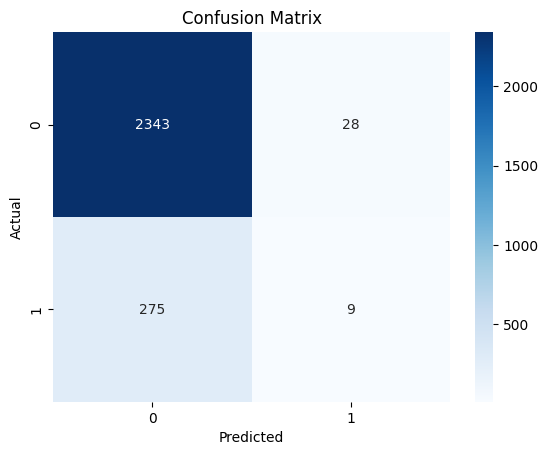

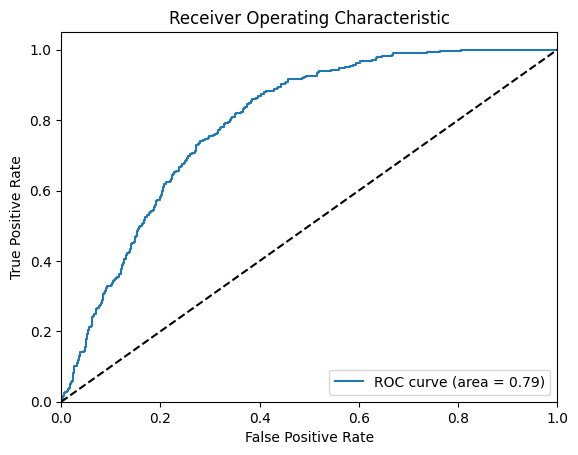

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# Define features and target variable
features = ['Amount', 'Term', 'ALL_AgeOfOldestAccount', 'ALL_AgeOfYoungestAccount',
            'ALL_Count', 'ALL_CountActive', 'ALL_CountClosedLast12Months',
            'ALL_CountDefaultAccounts', 'ALL_CountOpenedLast12Months',
            'ALL_CountSettled', 'ALL_MeanAccountAge',
            'ALL_SumCurrentOutstandingBal', 'ALL_SumCurrentOutstandingBalExcMtg',
            'ALL_TimeSinceMostRecentDefault', 'ALL_WorstPaymentStatusActiveAccounts',
            'ActiveAccountRatio', 'ClosedLast12MonthsRatio']
X = merged_data[features]
y = merged_data['Success']

# Handle infinite or very large values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

# Print accuracy
print(f'Accuracy: {accuracy:.2f}')

# Plot confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot ROC curve
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Discussion and Conclusion
In this notebook, we explored a dataset of loan applications, engineered features, and built a logistic regression model to predict loan success. The model achieved an accuracy of approximately 70%, indicating a reasonable predictive power. Future work could involve exploring more complex models, such as ensemble methods, to potentially improve prediction accuracy. Additionally, further feature engineering and hyperparameter tuning could enhance model performance.